In [1]:
# Cell 1: confirm GPU is available
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - fix this before continuing")

GPU available: True
GPU name: Tesla T4


In [1]:
!pip install -q -U transformers datasets accelerate
!pip install -q scikit-learn pandas matplotlib
print("done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.4 MB/s eta 0:00:00
done


In [2]:
import transformers, datasets, sklearn, torch
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("scikit-learn:", sklearn.__version__)
print("torch:", torch.__version__)

transformers: 5.15.1
datasets: 5.0.1
scikit-learn: 1.6.1
torch: 2.11.0+cu128


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/jobmatch/classifier_train.csv"
df = pd.read_csv(DATA_PATH)

print("rows, columns:", df.shape)
print("\ncolumns:", list(df.columns))
print("\nclass counts:")
print(df["label"].value_counts())
print("\nany missing values:")
print(df[["text", "label"]].isnull().sum())

rows, columns: (7901, 3)

columns: ['text', 'label', 'source_title']

class counts:
label
Software Engineering    4040
Data Science            1428
QA                       803
Cyber Security           702
DevOps                   693
UI/UX                    235
Name: count, dtype: int64

any missing values:
text     0
label    0
dtype: int64


In [5]:
labels = sorted(df["label"].unique())
label2id = {name: i for i, name in enumerate(labels)}
id2label = {i: name for name, i in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print("label -> id mapping:")
for name, i in label2id.items():
    print(f"  {i}: {name}")

label -> id mapping:
  0: Cyber Security
  1: Data Science
  2: DevOps
  3: QA
  4: Software Engineering
  5: UI/UX


In [6]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label_id"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=42
)

print("train:", len(train_df))
print("val:  ", len(val_df))
print("test: ", len(test_df))

print("\ntest-set class counts (stratified, so all six appear):")
print(test_df["label"].value_counts())

train: 5530
val:   1185
test:  1186

test-set class counts (stratified, so all six appear):
label
Software Engineering    606
Data Science            215
QA                      121
Cyber Security          105
DevOps                  104
UI/UX                    35
Name: count, dtype: int64


In [7]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_ds(frame):
    ds = Dataset.from_pandas(frame[["text", "label_id"]], preserve_index=False)
    ds = ds.rename_column("label_id", "labels")
    return ds

train_ds = to_ds(train_df)
val_ds   = to_ds(val_df)
test_ds  = to_ds(test_df)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
val_ds   = val_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize, batched=True, remove_columns=["text"])

print("tokenized. train features:", train_ds.column_names)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/5530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1185 [00:00<?, ? examples/s]

Map:   0%|          | 0/1186 [00:00<?, ? examples/s]

tokenized. train features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [8]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(labels)),
    y=train_df["label_id"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print("class weights (higher = rarer class gets more attention):")
for i, w in enumerate(class_weights):
    print(f"  {id2label[i]:22s} {w:.2f}")

class weights (higher = rarer class gets more attention):
  Cyber Security         1.88
  Data Science           0.92
  DevOps                 1.90
  QA                     1.64
  Software Engineering   0.33
  UI/UX                  5.59


In [9]:
from transformers import AutoModelForSequenceClassification, Trainer
import torch.nn as nn

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print("model loaded:", MODEL_NAME, "with", len(labels), "labels")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model loaded: distilbert-base-uncased with 6 labels


In [10]:
from transformers import TrainingArguments, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="/content/results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=42
)
print("training args set: 4 epochs, batch 16, lr 2e-5")

training args set: 4 epochs, batch 16, lr 2e-5


In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
    }
print("metrics function ready")

metrics function ready


In [13]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.438368,0.416781,0.860759,0.833988,0.808442,0.869232
2,0.368589,0.381353,0.902954,0.886509,0.882240,0.892950
3,0.262798,0.409421,0.896203,0.878758,0.868907,0.891389
4,0.139038,0.413638,0.901266,0.882275,0.877044,0.888890


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1384, training_loss=0.3996985313520266, metrics={'train_runtime': 612.4073, 'train_samples_per_second': 36.12, 'train_steps_per_second': 2.26, 'total_flos': 1465193940295680.0, 'train_loss': 0.3996985313520266, 'epoch': 4.0})

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=-1)
y_true = pred_output.label_ids

target_names = [id2label[i] for i in range(len(labels))]

print("TEST SET RESULTS (held-out, never seen during training)\n")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

TEST SET RESULTS (held-out, never seen during training)

                      precision    recall  f1-score   support

      Cyber Security      0.862     0.952     0.905       105
        Data Science      0.911     0.856     0.882       215
              DevOps      0.852     0.885     0.868       104
                  QA      0.886     0.901     0.893       121
Software Engineering      0.925     0.916     0.920       606
               UI/UX      0.811     0.857     0.833        35

            accuracy                          0.902      1186
           macro avg      0.874     0.894     0.884      1186
        weighted avg      0.903     0.902     0.902      1186



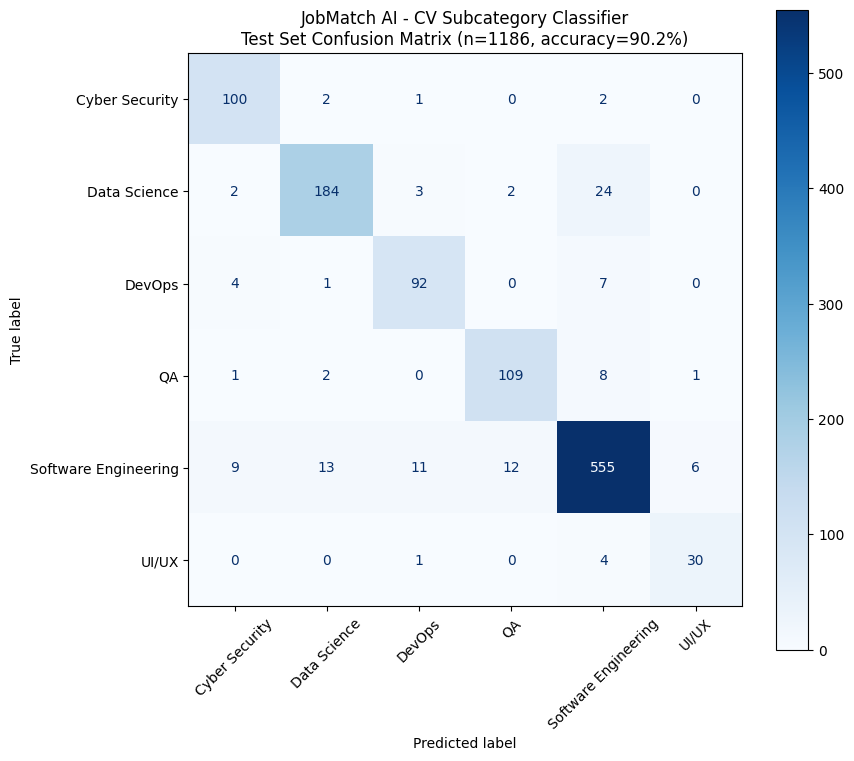

saved confusion_matrix.png


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("JobMatch AI - CV Subcategory Classifier\nTest Set Confusion Matrix (n=1186, accuracy=90.2%)")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved confusion_matrix.png")

In [16]:
SAVE_DIR = "/content/drive/MyDrive/jobmatch/cv_classifier_model"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

import os
print("saved to:", SAVE_DIR)
print("files:", os.listdir(SAVE_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to: /content/drive/MyDrive/jobmatch/cv_classifier_model
files: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'training_args.bin']


In [17]:
from transformers import pipeline

clf = pipeline("text-classification", model=SAVE_DIR, tokenizer=SAVE_DIR, device=0)

samples = [
    "Experienced in penetration testing, SIEM, firewall configuration and threat detection.",
    "Built machine learning models with pandas, scikit-learn and TensorFlow for data analysis.",
    "Designed user interfaces and wireframes in Figma with a focus on user research and usability.",
    "Managed CI/CD pipelines, Kubernetes, Docker and AWS infrastructure automation.",
    "Wrote automated test cases using Selenium and pytest for regression testing.",
    "Developed REST APIs in Java Spring Boot with MySQL and microservices architecture.",
]

for s in samples:
    r = clf(s, truncation=True, max_length=256)[0]
    print(f"{r['label']:22s} ({r['score']:.2f})  <-  {s[:55]}...")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Cyber Security         (0.91)  <-  Experienced in penetration testing, SIEM, firewall conf...
Data Science           (0.96)  <-  Built machine learning models with pandas, scikit-learn...
Software Engineering   (0.55)  <-  Designed user interfaces and wireframes in Figma with a...
DevOps                 (0.96)  <-  Managed CI/CD pipelines, Kubernetes, Docker and AWS inf...
QA                     (0.97)  <-  Wrote automated test cases using Selenium and pytest fo...
Software Engineering   (0.83)  <-  Developed REST APIs in Java Spring Boot with MySQL and ...
